TensorFlow version: 2.19.0

--- Step 1: Training a CNN Classifier with CIFAR-10 ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,738 (444.29 KB)

 Trainable params: 113,738 (444.29 KB)

 Non-trainable params: 0 (0.00 B)

Training model (this might take a moment)...
Model trained with accuracy: 0.5261

--- Step 2: Applying LIME to individual predictions ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Explaining prediction for image at index 0:
True label: 3, Predicted label: 3
Generating LIME explanation (this might take a moment)...


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

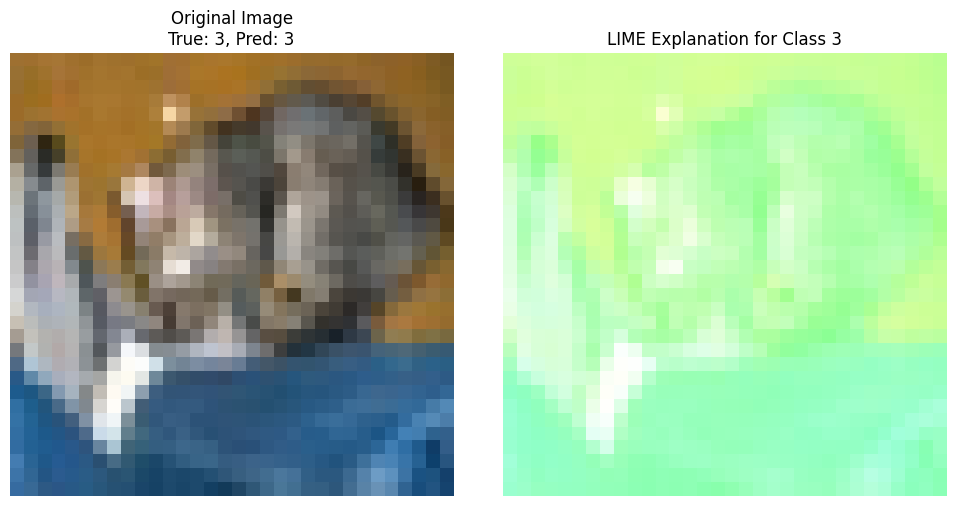


Interpretation: The highlighted regions in the LIME explanation image (right) indicate the pixels (superpixels) that contribute most significantly to the model's prediction for the displayed class. Red regions usually indicate features that support the prediction, while blue regions indicate features that contradict it (or make the model predict another class).


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Install LIME if not already installed
try:
    import lime
    import lime.lime_image
except ImportError:
    print("LIME not found. Installing...")
    !pip install lime
    import lime
    import lime.lime_image

# Install scikit-image if not already installed, as it's often needed by LIME for mark_boundaries
try:
    import skimage.segmentation
except ImportError:
    print("scikit-image not found. Installing...")
    !pip install scikit-image


print("TensorFlow version:", tf.__version__)

# --- Step 1: Train CNN Classifier ---+
print("\n--- Step 1: Training a CNN Classifier with CIFAR-10 ---")

# Load and preprocess the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Build a simple CNN model for CIFAR-10
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)), # CIFAR-10 images are 32x32x3
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Train the model (using a smaller subset for faster demonstration)
print("Training model (this might take a moment)...")
history = model.fit(x_train[:10000], y_train[:10000], batch_size=128, epochs=5, validation_split=0.1, verbose=0)

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Model trained with accuracy: {accuracy:.4f}")

# --- Step 2: Apply LIME to individual predictions ---
print("\n--- Step 2: Applying LIME to individual predictions ---")

# Choose an image from the test set to explain
image_index = 0  # You can change this index to explain different images
image_to_explain = x_test[image_index]
true_label = np.argmax(y_test[image_index])
predicted_label = np.argmax(model.predict(np.expand_dims(image_to_explain, axis=0))[0])

print(f"Explaining prediction for image at index {image_index}:")
print(f"True label: {true_label}, Predicted label: {predicted_label}")

# Define the prediction function for LIME
# LIME expects a function that takes a numpy array of images and returns a numpy array of probabilities
def predict_fn(images):
    # Ensure images are in the correct format (e.g., 4D tensor if CNN expects it)
    # LIME for color images expects (H, W, C) where C=3, and predict_fn needs to handle batch dimension.
    if images.ndim == 3: # If LIME passes a single image (H, W, C)
        images = np.expand_dims(images, axis=0)
    return model.predict(images)

# Initialize LIME explainer
explainer = lime.lime_image.LimeImageExplainer()

# Explain the instance
print("Generating LIME explanation (this might take a moment)...")
explanation = explainer.explain_instance(
    image_to_explain, # Pass the original 3D image (H, W, C)
    predict_fn,
    top_labels=5,
    hide_color=0, # Use a color for hiding regions (e.g., black)
    num_samples=1000 # Number of perturbations to generate
)

# --- Step 3: Interpret feature contributions ---
print("\n--- Step 3: Interpreting Feature Contributions ---")

# Get image and mask for the top predicted class
temp_img, mask = explanation.get_image_and_mask(
    explanation.top_labels[0], # Explanation for the top predicted label
    positive_only=False, # Show both positive and negative contributions
    num_features=5, # Number of features (superpixels) to highlight
    hide_rest=False # Do not hide the rest of the image
)

# Visualize the original image and the LIME explanation
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image_to_explain) # No cmap='gray' for color images
ax[0].set_title(f"Original Image\nTrue: {true_label}, Pred: {predicted_label}")
ax[0].axis('off')

from skimage.segmentation import mark_boundaries
ax[1].imshow(mark_boundaries(temp_img / 2 + 0.5, mask)) # LIME often returns images scaled from -1 to 1
ax[1].set_title(f"LIME Explanation for Class {explanation.top_labels[0]}")
ax[1].axis('off')

plt.tight_layout()
plt.show()

print("\nInterpretation: The highlighted regions in the LIME explanation image (right) indicate the pixels (superpixels) that contribute most significantly to the model's prediction for the displayed class. Red regions usually indicate features that support the prediction, while blue regions indicate features that contradict it (or make the model predict another class).")